PROBLEM STATEMENT : Air pollution has become a major environmental and public health concern due to rapid urbanization and industrial growth. Poor air quality can lead to serious health problems such as respiratory diseases, cardiovascular disorders, and reduced life expectancy. Continuous monitoring and accurate prediction of air quality are essential for taking preventive measures and spreading public awareness.

OBJECTIVE : The main objective of this project is to develop a machine learning model that accurately predicts air quality levels (AQI or pollutant concentration) based on various environmental and atmospheric parameters. The project aims to analyze historical air pollution data, identify significant features affecting air quality, and build an optimized predictive model using regression algorithms.

TARGET VARIABLE : In this project we are supposed to predict AQI based on key features such as 	location,	pm2.5,	pm10,	temperature. Since the target variable predicted_aqi is continuous in nature this problem will e formulated as a regression task

DATA DESCRIPTION : The dataset consists of 1460 observations and 7 columns capturing both numerical and categorical attributes related to AQI.

1.date: Measurement date

2.location: City name

3.pm2.5: Particulate matter 2.5 concentration

4.pm10: Particulate matter 10 concentration

5.temperature: Daily average temperature (°C)

6.predicted_aqi: Calculated AQI based on the other variables

PREPROCESSING EDA & CHALLENGES FACED :

1.Null check and processing - there are no nulls present in the data

2.Duplicate check and processing - no duplicates present in data

3.Statistical distribution check - here checking for the min value and max value of different columns as well as their distribution by comparing mean and median it is found that most of the column are normally distributed.

4.Outlier identified using Seaborn boxplots - Outliers were detected using boxplots during EDA; however, they were not removed as they represent genuine pollution events in air quality data. Retaining these values helps the model capture real-world extreme conditions

5.Skewness removal and check - Since no substantial skewness was observed, no transformation techniques such as log or power transformation were applied. This helped preserve the original scale and interpretability of the air quality variables while maintaining model performance.

6.Object encoding - The Location feature was encoded using ordinal encoding to convert categorical values into numerical form while avoiding dimensionality expansion. The encoded values act as identifiers and do not represent any ranking among locations.

7.Data scaling - since the features are already normally distributed after outlier treatment the standard scaling was applied to bring all numerical features to a common scale enuring fair contribution to the regression model here all the numerical features are standardized to have 0 mean and unit variance to improve model stability and interpretability the target variable is not scaled because it represents the actual ouput value and scaling it can reduce interpretability and complicate result interpretation without benefiting most models for eg. linear regression , Polynomial Features,  decision tree regressor , randomn forest regressor etc. 

APPLIED MODELS AND PERFORMANCE :


Multiple regression models were implemented and evaluated for the air quality prediction task, including Linear Regression, Polynomial Regression, Decision Tree Regressor, and Random Forest Regressor.

1.Linear Regression  achieved the highest performance with an R² score of 0.7776, indicating that approximately 77.76% of the variance in air quality was explained by the model.

2.Polynomial Regression was applied to capture non-linear patterns; however, increasing the polynomial degree did not improve performance, suggesting that the added model complexity did not contribute additional predictive power and risked overfitting.

3.The Decision Tree Regressor achieved perfect performance on the training data but showed significantly lower testing performance, indicating severe overfitting. After hyperparameter tuning using GridSearchCV, the Decision Tree model showed improved generalization, though performance remained limited compared to ensemble methods.

4.The Random Forest Regressor performed better than Decision Tree with a testing R² score of 0.7110, demonstrating good generalization ability, but it still did not surpass Linear Regression.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
aqp=pd.read_csv('16_air_quality_prediction.csv')
aqp.head()

,date,location,pm2.5,pm10,temperature,predicted_aqi
0,2023-01-01,Istanbul,29.05,58.73,15.4,40.71
1,2023-01-01,Ankara,24.74,83.86,26.4,50.63
2,2023-01-01,Izmir,23.90,76.91,27.8,39.67
3,2023-01-01,Bursa,43.67,49.58,30.6,36.50
4,2023-01-02,Istanbul,28.40,76.31,23.9,46.89


In [6]:
aqp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   location       1460 non-null   object 
 1   pm2.5          1460 non-null   float64
 2   pm10           1460 non-null   float64
 3   temperature    1460 non-null   float64
 4   predicted_aqi  1460 non-null   float64
 5   month          1460 non-null   int32  
 6   day_of_week    1460 non-null   int32  
dtypes: float64(4), int32(2), object(1)
memory usage: 68.6+ KB


In [3]:
aqp['date'] = pd.to_datetime(aqp['date']) 
aqp['year'] = aqp['date'].dt.year
aqp['month'] = aqp['date'].dt.month
aqp['day_of_week'] = aqp['date'].dt.dayofweek


In [4]:
aqp.drop(['date','year'],axis=1,inplace=True)
aqp

,location,pm2.5,pm10,temperature,predicted_aqi,month,day_of_week
0,Istanbul,29.05,58.73,15.4,40.71,1,6
1,Ankara,24.74,83.86,26.4,50.63,1,6
2,Izmir,23.90,76.91,27.8,39.67,1,6
3,Bursa,43.67,49.58,30.6,36.50,1,6
4,Istanbul,28.40,76.31,23.9,46.89,1,0
...,...,...,...,...,...,...,...
1455,Bursa,32.45,92.85,19.0,54.18,12,5
1456,Istanbul,35.23,63.02,23.2,46.39,12,6
1457,Ankara,45.30,47.77,8.4,44.05,12,6
1458,Izmir,37.29,64.74,30.9,52.19,12,6


### Output:
The date column was first converted into datetime format using pd.to_datetime() to enable date-based feature extraction.

In [5]:
aqp.shape

(1460, 7)

In [7]:
aqp.describe()

,pm2.5,pm10,temperature,predicted_aqi,month,day_of_week
count,1460.00000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,35.06900,69.815788,20.006644,44.493281,6.526027,3.008219
std,10.08376,19.665744,8.826885,9.543069,3.449033,2.004091
min,2.94000,-0.190000,5.100000,15.000000,1.000000,0.000000
25%,28.59750,56.887500,12.000000,38.045000,4.000000,1.000000
50%,35.23000,70.025000,19.850000,44.765000,7.000000,3.000000
75%,41.59500,82.572500,27.800000,50.825000,10.000000,5.000000
max,67.08000,142.220000,35.000000,78.930000,12.000000,6.000000


### Output:
The dataset consists of both numerical and categorical variables.
Numerical features include PM2.5, PM10, Temperature etc. 
Summary statistics indicate variations in pollutant levels, with noticeable differences in mean and maximum values.


In [8]:
aqp.isnull().sum()

location         0
pm2.5            0
pm10             0
temperature      0
predicted_aqi    0
month            0
day_of_week      0
dtype: int64

### Output:
No Missing values were identified in  air quality parameters.


In [9]:
aqp.duplicated().sum()

np.int64(0)

### Output:
No duplicated values were found in air quality parameters.


In [10]:
aqp.columns

Index(['location', 'pm2.5', 'pm10', 'temperature', 'predicted_aqi', 'month',
       'day_of_week'],
      dtype='object')

In [11]:
num_cols=[['pm2.5', 'pm10', 'temperature']]

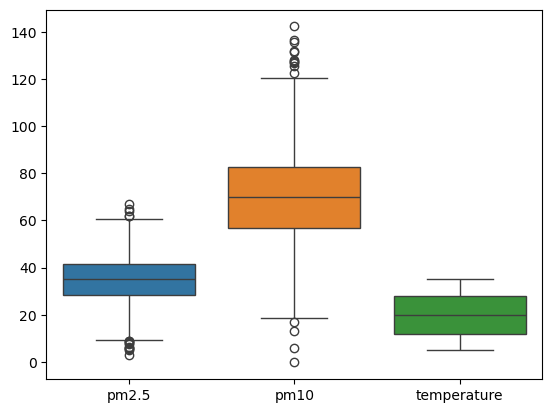

In [12]:
for i in num_cols:
    sns.boxplot(aqp[i])
    plt.show()

### Output:
Boxplots revealed the presence of extreme values in pollutant variables such as PM2.5 and PM10.
These outliers correspond to real pollution events and were therefore retained to preserve real-world data characteristics.


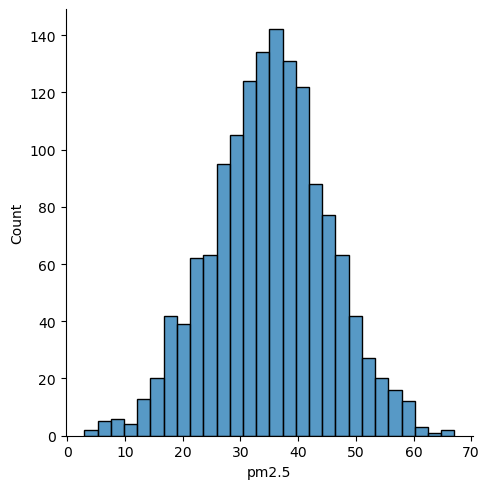

In [13]:
sns.displot(aqp, x="pm2.5")

### Output:
The PM2.5 values follow an approximately normal distribution with most values concentrated between 25 and 45.
The peak occurs around 35–40, and no significant outliers are observed.

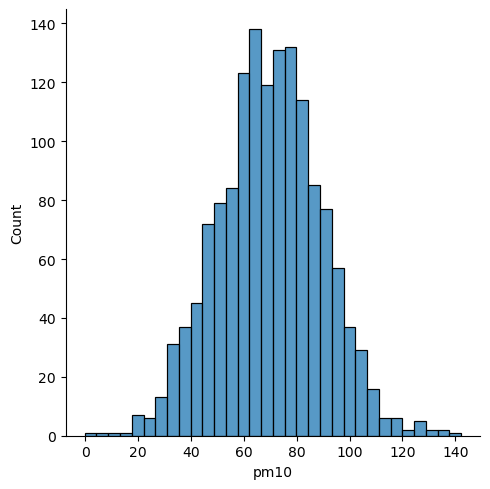

In [14]:
sns.displot(aqp, x="pm10")

### Output:
The PM10 values show an approximately normal distribution, with most values between 50 and 90 and a peak around 65–75.
The data does not show significant skewness or extreme outliers.

<Axes: >

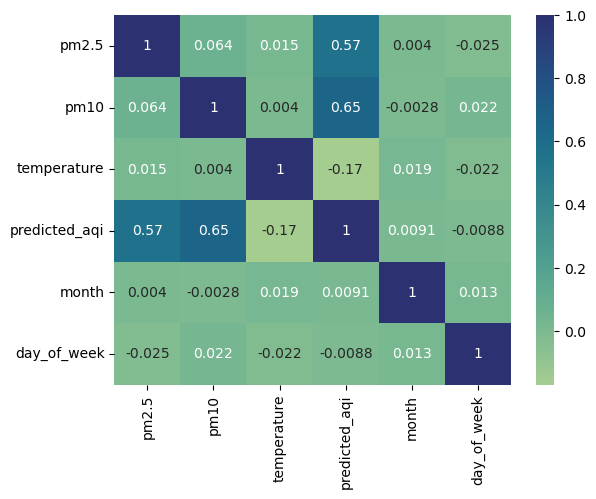

In [15]:
sns.heatmap(aqp[['pm2.5', 'pm10', 'temperature', 'predicted_aqi', 'month',
       'day_of_week']].corr(),annot=True,cmap="crest")

### Output:
The heatmap shows that PM10 (0.65) and PM2.5 (0.57) have strong positive correlation with AQI, indicating they are key predictors.
Temperature has weak negative correlation, while month and day_of_week have minimal impact.

<Axes: ylabel='Density'>

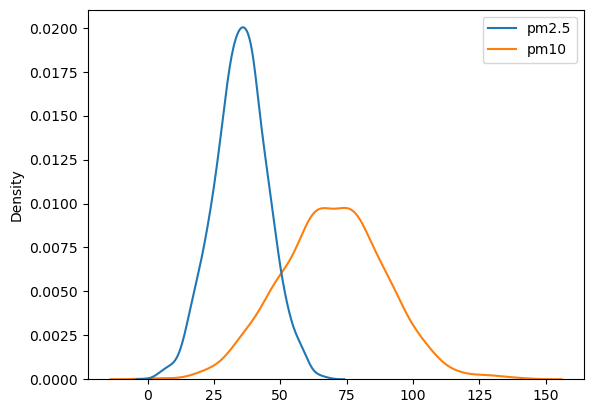

In [16]:
sns.kdeplot(aqp[["pm2.5","pm10"]])

### Output:
The KDE plot shows that PM2.5 and PM10 follow smooth, unimodal distributions.
While both variables approximately resemble a normal distribution, they exhibit positive skewness, with PM10 showing greater variability and deviation from normality than PM2.5.

In [17]:
from scipy.stats import skew
for i in num_cols:
    print(f"{i}:{skew(aqp[i])}")

['pm2.5', 'pm10', 'temperature']:[-0.06106625  0.05723113  0.03323741]


### Output:
Skewness analysis showed that the feature distributions were approximately symmetric, and no significant skewness was observed.
Hence, no transformation techniques were applied.


In [18]:
obj_cols=aqp.select_dtypes('object').columns
obj_cols

Index(['location'], dtype='object')

In [19]:
for i in obj_cols:
    print(i,":",aqp[i].nunique(),"Unique Values\n",aqp[i].value_counts(),"\n")

location : 4 Unique Values
 location
Istanbul    365
Ankara      365
Izmir       365
Bursa       365
Name: count, dtype: int64 



In [20]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
aqp[obj_cols]=enc.fit_transform(aqp[obj_cols])
aqp

,location,pm2.5,pm10,temperature,predicted_aqi,month,day_of_week
0,2.0,29.05,58.73,15.4,40.71,1,6
1,0.0,24.74,83.86,26.4,50.63,1,6
2,3.0,23.90,76.91,27.8,39.67,1,6
3,1.0,43.67,49.58,30.6,36.50,1,6
4,2.0,28.40,76.31,23.9,46.89,1,0
...,...,...,...,...,...,...,...
1455,1.0,32.45,92.85,19.0,54.18,12,5
1456,2.0,35.23,63.02,23.2,46.39,12,6
1457,0.0,45.30,47.77,8.4,44.05,12,6
1458,3.0,37.29,64.74,30.9,52.19,12,6


### Output:
The categorical Location feature was successfully encoded into numerical form using ordinal encoding,
enabling its use in machine learning models without increasing dimensionality.


In [21]:
target=aqp["predicted_aqi"]
features=aqp.drop("predicted_aqi",axis=1)

In [22]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
features.iloc[:]=scaler.fit_transform(features.iloc[:])

In [23]:
features.head()

,location,pm2.5,pm10,temperature,month,day_of_week
0,0.447214,-0.597105,-0.563904,-0.522067,-1.602745,1.493348
1,-1.341641,-1.024671,0.714391,0.724553,-1.602745,1.493348
2,1.341641,-1.108002,0.360863,0.883214,-1.602745,1.493348
3,-0.447214,0.853248,-1.029339,1.200535,-1.602745,1.493348
4,0.447214,-0.661587,0.330343,0.441230,-1.602745,-1.501553


### Output:
Numerical features were standardized using Standard Scaler, resulting in features with zero mean and unit variance.
This ensures consistent feature contribution during model training.


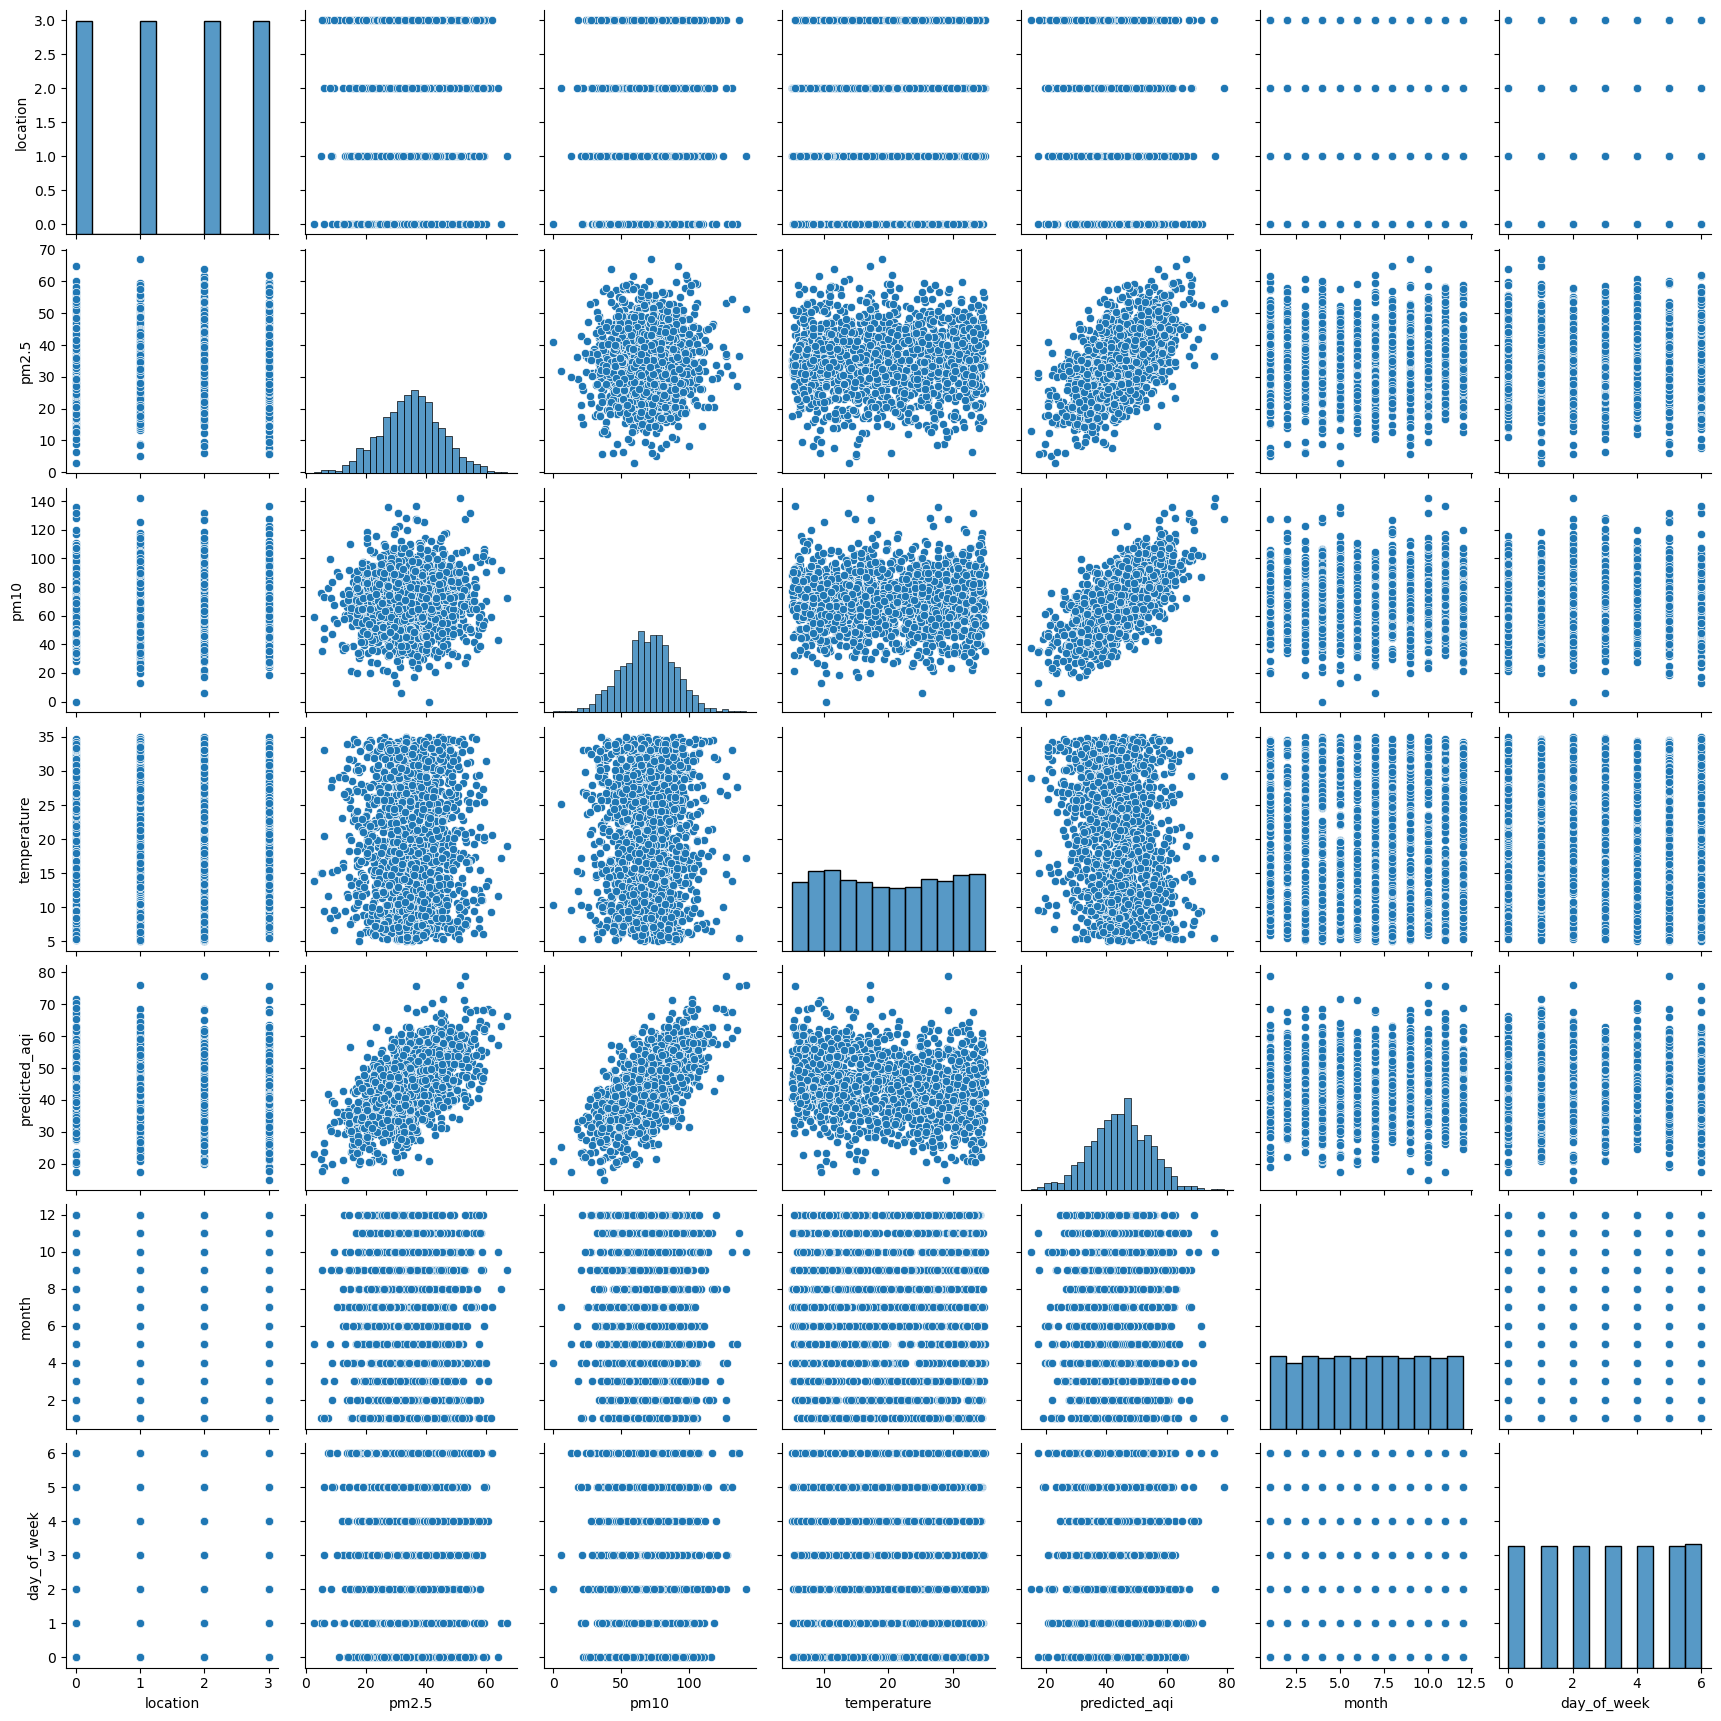

In [24]:
sns.pairplot(aqp)

### Output:
The pairplot illustrates the pairwise relationships between PM2.5 and PM10 concentrations.
The diagonal plots show the individual distributions of each variable, while the off-diagonal plots indicate a positive correlation between PM2.5 and PM10.
This suggests that increases in fine particulate matter are often associated with increases in coarse particulate matter, which is consistent with real-world air pollution behavior.


In [25]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(features,target,random_state=1,test_size=0.20)
print(xtrain.shape,ytrain.shape)
print(xtest.shape,ytest.shape)

(1168, 6) (1168,)
(292, 6) (292,)


### Output:
The dataset was split into training and testing sets to evaluate model performance on unseen data.
The split was performed while preserving the temporal structure of the data.


In [26]:
X = aqp.drop("predicted_aqi", axis=1)   
y = aqp["predicted_aqi"]               



In [27]:
from sklearn.linear_model import LinearRegression
lr1=LinearRegression()
lr1.fit(xtrain,ytrain)
ypred=lr1.predict(xtest)
from sklearn.metrics import mean_squared_error  , r2_score
mser=mean_squared_error(ytest,ypred)
r2=r2_score(ytest,ypred)
print("mse:",mser)
print("R2",r2)

mse: 23.812390683365052
R2 0.774729018054266


In [28]:
print("Training Score:",lr1.score(xtrain,ytrain))
print("Testing Score:",lr1.score(xtest,ytest))

Training Score: 0.7264098960582717
Testing Score: 0.774729018054266


In [29]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(lr1, X, y, cv=5, scoring='r2')

print("Cross Validation Scores:", scores)
print("Average Score:", scores.mean())

Cross Validation Scores: [0.70328711 0.77365917 0.72703298 0.74180236 0.71122151]
Average Score: 0.7314006253663388


### Output:
The Linear Regression model achieved a training score of 0.726 and a testing score of 0.775, indicating good performance on unseen data.  
Cross-validation with 5 folds produced scores ranging between 0.703 and 0.774, with an average R² of 0.731.  
This shows that while the single train-test split gave a slightly higher testing score (0.775), cross-validation provides a more reliable estimate of the model’s generalization ability, averaging around 0.731.  
Overall, the model is consistent, but cross-validation highlights that its true performance is slightly lower than the single test split suggests.




<Axes: ylabel='predicted_aqi'>

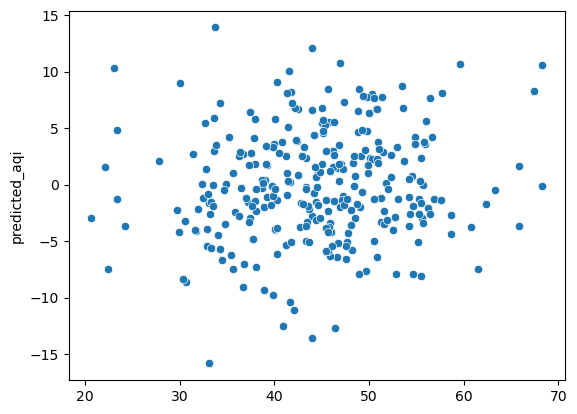

In [30]:
sns.scatterplot(x=ypred,y=(ytest-ypred))

### Output:
The scatter plot of predicted AQI values versus residuals shows a random dispersion of points without a clear pattern.
This indicates that the variance of errors is approximately constant across predictions, suggesting the absence of heteroscedasticity and confirming that the model captures the underlying relationship reasonably well.


<Axes: xlabel='predicted_aqi', ylabel='Density'>

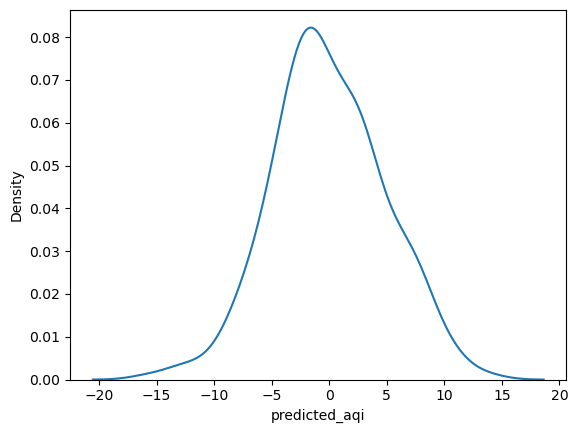

In [31]:
sns.kdeplot((ytest-ypred))

### Output:
The KDE plot of residuals shows a unimodal distribution centered approximately around zero, indicating that the prediction errors are randomly distributed.
This suggests that the model does not exhibit systematic bias and that overestimation and underestimation occur with similar frequency.
The smooth distribution implies stable model behavior.


In [32]:
from sklearn.preprocessing import PolynomialFeatures
for i in range(2, 8):
    poly = PolynomialFeatures(degree=i)
    xtrainp = poly.fit_transform(xtrain)
    xtestp = poly.transform(xtest)
    print(f"degree {i} : {xtrainp.shape}")
    lr = LinearRegression()
    lr.fit(xtrainp, ytrain)
    ypred = lr.predict(xtestp)
    mse = mean_squared_error(ytest, ypred)
    r2 = r2_score(ytest, ypred)
    print(f"MSE : {mse}")
    print(f"R2 (Model Accuracy) : {r2}")
    print("-" * 40)

degree 2 : (1168, 28)
MSE : 24.506444633779598
R2 (Model Accuracy) : 0.7681630996207831
----------------------------------------
degree 3 : (1168, 84)
MSE : 26.346895778134552
R2 (Model Accuracy) : 0.7507519861368429
----------------------------------------
degree 4 : (1168, 210)
MSE : 33.11717871271392
R2 (Model Accuracy) : 0.6867034701771
----------------------------------------
degree 5 : (1168, 462)
MSE : 76.88745621349486
R2 (Model Accuracy) : 0.2726260462111666
----------------------------------------
degree 6 : (1168, 924)
MSE : 5150.329252982887
R2 (Model Accuracy) : -47.723361866131505
----------------------------------------
degree 7 : (1168, 1716)
MSE : 30028.220205118
R2 (Model Accuracy) : -283.0742343613245
----------------------------------------


In [33]:
scores = cross_val_score(lr, X, y, cv=5, scoring='r2')

print("Cross Validation Scores:", scores)
print("Average Score:", scores.mean())

Cross Validation Scores: [0.70328711 0.77365917 0.72703298 0.74180236 0.71122151]
Average Score: 0.7314006253663388


### Output:
Cross-validation confirms that degree 2 polynomial regression generalizes best, with an average R² of ~0.73, closely matching the single split score. Higher degrees lead to severe overfitting and poor generalization.

In [34]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [35]:
from sklearn.metrics import mean_squared_error,r2_score
def mymodel(model):
    model.fit(xtrain,ytrain)
    ypred=model.predict(xtest)
    #overfitting-underfitting check
    print(f"Training Score:{model.score(xtrain,ytrain)}")
    print(f"Testing Score: {model.score(xtest,ytest)}")
    mse=mean_squared_error(ytest,ypred)
    r2=r2_score(ytest,ypred)
    print(f"mse :{mse}")
    print(f"r2 (Model Accuracy): {r2}")
    sns.scatterplot(x=ypred,y=(ytest-ypred))
    plt.show()
    sns.kdeplot((ytest-ypred))
    plt.show()
    return model

Training Score:1.0
Testing Score: 0.521281727329995
mse :50.60317328767123
r2 (Model Accuracy): 0.521281727329995


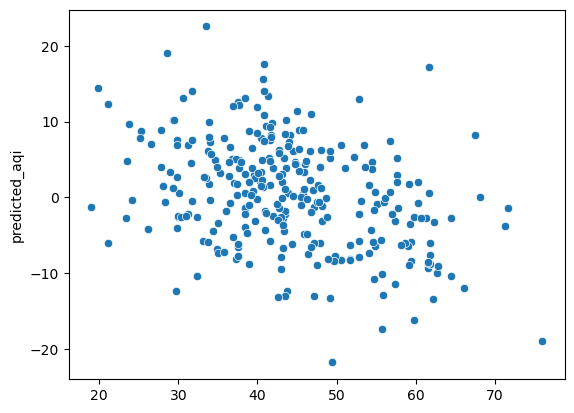

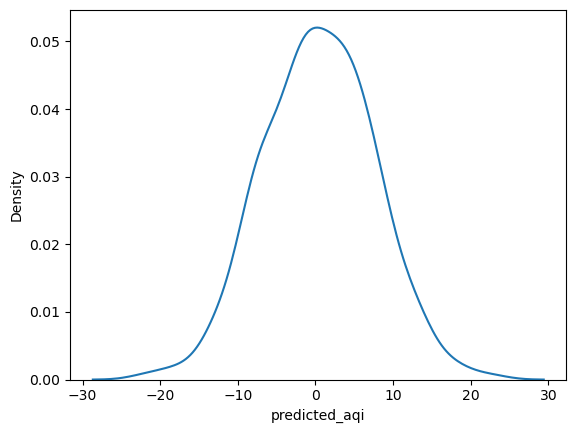

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [36]:
dt=mymodel(DecisionTreeRegressor())
dt

### Overfitting Analysis:
The large gap between the training score (1.0) and testing score (0.49) indicates that the Decision Tree Regressor is overfitting the training data.
The model captures noise and extreme patterns present in the training set, which reduces its ability to generalize to new data.
To reduce overfitting, hyperparameters such as max_depth, min_samples_split, and min_samples_leaf should be tuned.



In [37]:
parameters={
    "max_depth":list(range(2,5)),
    "min_samples_split":list(range(2,5)),
    "min_samples_leaf":list(range(3,5)),
    "criterion":["squared_error","absolute_error"]
}
clf=GridSearchCV(DecisionTreeRegressor(),parameters,verbose=2)
clf.fit(xtrain,ytrain)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=3; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=3; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=3; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_spl

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'absolute_error'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [3, 4], 'min_samples_split': [2, 3, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


Training Score:0.6635584504488703
Testing Score: 0.5932589032663531
mse :42.99478707264271
r2 (Model Accuracy): 0.5932589032663531


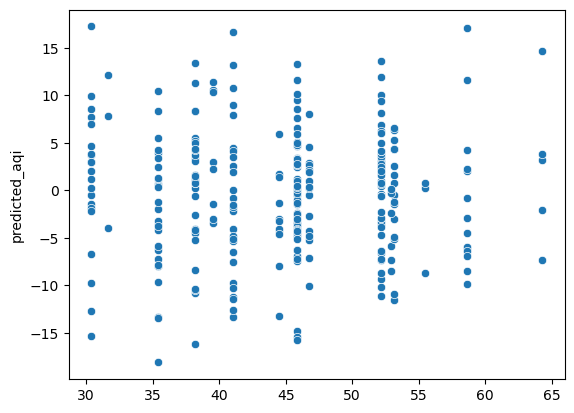

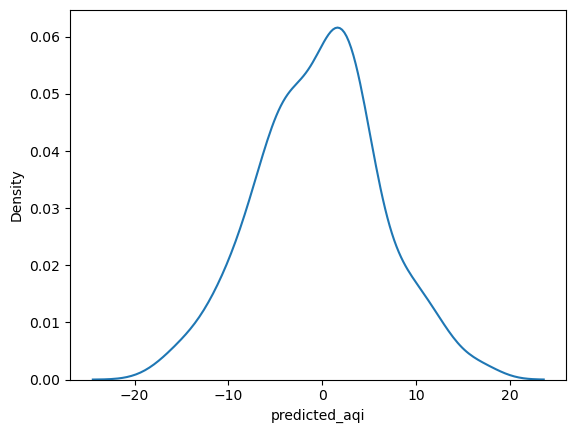

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [38]:
dt_ht=mymodel(clf.best_estimator_)
dt_ht

### Decision Tree Regressor After Hyperparameter Tuning:

GridSearchCV was applied to optimize the Decision Tree Regressor by tuning hyperparameters such as max_depth, min_samples_split, min_samples_leaf, and criterion.
The best estimator obtained from GridSearchCV was then trained and evaluated on the test dataset.
After hyperparameter tuning, the training score reduced to approximately 0.66 and the testing score improved to approximately 0.59.
This reduction in training performance along with improvement in testing performance indicates a significant reduction in overfitting.


Training Score:0.9544538670151413
Testing Score: 0.7218403261069841
mse :29.40301839982877
r2 (Model Accuracy): 0.7218403261069841


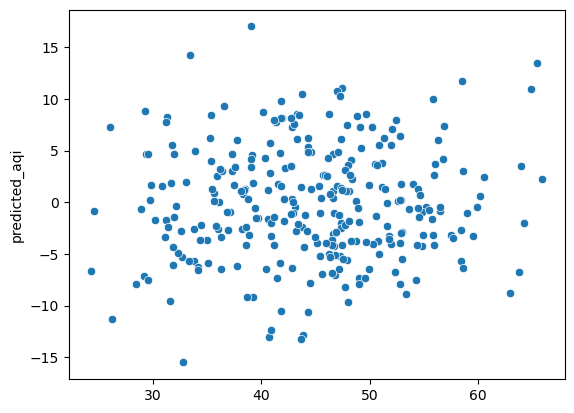

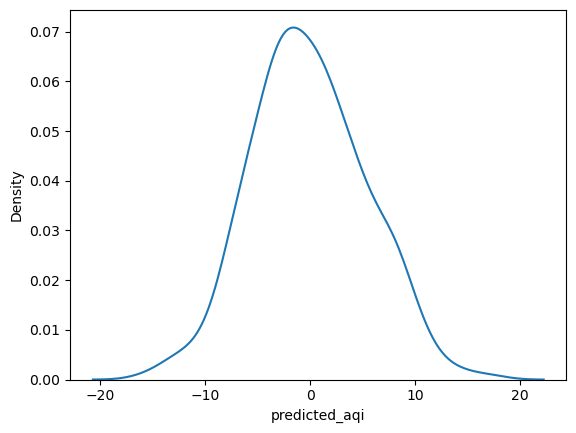

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
rf=mymodel(RandomForestRegressor())
rf

### Random Forest Regressor – Model Performance:

The Random Forest Regressor achieved a training score of approximately 0.95 and a testing score of approximately 0.72.
The close alignment between training and testing scores indicates good generalization performance with minimal overfitting.
The Mean Squared Error (MSE) value of approximately 30.24 shows reduced prediction error compared to single Decision Tree models.
The R² score of 0.72 indicates that the model explains about 72% of the variance in the target variable.
